# 5. Experimenting part 1

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None)

In [15]:
df = pd.read_csv('../data/processed/data_after_feature_engineering.csv')

In [19]:
non_numeric = df.columns.difference(df.select_dtypes(include=[np.number]).columns)
df.drop(columns=non_numeric, inplace=True)

In [21]:
df.drop(columns=['Reactions', 'ID'], inplace=True)

In [22]:
df.head(3)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,20,81,15.424949,9.105091,185,75,73,74,71.0,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.2,74.0,68.2,10.0
1,23,87,17.516813,10.491302,179,73,85,79,84.0,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.4,79.6,40.4,10.6
2,16,88,15.607270,10.275086,170,68,92,89,85.0,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.6,64.8,38.2,9.8


In [23]:
import statsmodels.api

### Linear Regression (Let's tune more)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Value'])
y = df['Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print (f'MSE: {mean_squared_error(y_test, y_pred)}')
print (f'R2 Score: {r2_score(y_test, y_pred)}')

MSE: 0.13352856049923817
R2 Score: 0.9352558145490311


In [25]:
comparison_df = pd.DataFrame({'Original': y_test, 'Predicted': y_pred})
print(comparison_df)

       Original  Predicted
4355  13.171155  13.038865
3209  14.946913  15.813033
4127  13.910822  13.735233
6608  13.017005  13.125900
7533  13.171155  13.083092
3844  13.623140  13.155209
6756  13.217675  13.155236
7324  13.493928  13.384508
6991  14.457365  14.293450
8437  14.077876  13.931634
6221  12.611541  12.759424
2439  11.407576  12.028074
8623  13.652993  13.479042
6560  14.880222  14.743371
6474  13.171155  13.169912
457   16.906553  15.944459
3404  13.710151  13.908905
2615  16.972511  16.527396
1614  14.808763  14.768172
3122  17.989898  17.044836
1297  15.096445  15.510933
2922  14.914123  15.098267
3131  14.557448  15.112287
318   17.111347  16.458554
1765  14.508658  14.271835
5152  12.043560  11.815136
1314  13.997833  13.935923
119   17.426428  17.361623
2075  13.458837  13.442088
8808  12.834684  12.869217
5532  11.695255  11.979953
93    15.761421  15.705830
2002  15.520259  15.537764
6599  13.262127  13.355860
3151  13.384729  13.384172
8384  12.429220  12.436691
5

In [26]:
y_pred_original = np.exp(y_pred)

comparison_df_original = pd.DataFrame({'Original': np.exp(y_test), 'Predicted': y_pred_original})
print(comparison_df_original)

         Original     Predicted
4355     525001.0  4.599463e+05
3209    3100001.0  7.370773e+06
4127    1100001.0  9.228606e+05
6608     450001.0  5.017713e+05
7533     525001.0  4.807449e+05
3844     825001.0  5.166954e+05
6756     550001.0  5.167094e+05
7324     725001.0  6.498574e+05
6991    1900001.0  1.612747e+06
8437    1300001.0  1.123135e+06
6221     300001.0  3.478143e+05
2439      90001.0  1.673887e+05
8623     850001.0  7.142880e+05
6560    2900001.0  2.529092e+06
6474     525001.0  5.243485e+05
457    22000001.0  8.406024e+06
3404     900001.0  1.097895e+06
2615   23500001.0  1.505764e+07
1614    2700001.0  2.592602e+06
3122   65000001.0  2.526261e+07
1297    3600001.0  5.448947e+06
2922    3000001.0  3.606568e+06
3131    2100001.0  3.657489e+06
318    27000001.0  1.405592e+07
1765    2000001.0  1.578263e+06
5152     170001.0  1.352846e+05
1314    1200001.0  1.127962e+06
119    37000001.0  3.467824e+07
2075     700001.0  6.883740e+05
8808     375001.0  3.881772e+05
5532    

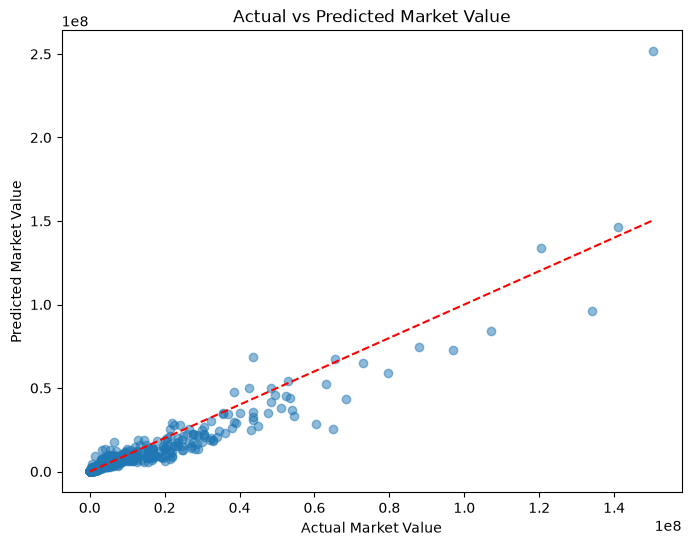

In [27]:
import matplotlib.pyplot as plt

actual_values = np.exp(y_test)
predicted_values = y_pred_original

plt.figure(figsize=(8, 6))
plt.scatter(actual_values, predicted_values, alpha=0.5)
plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', linestyle='dashed')  # perfect predictions line
plt.xlabel("Actual Market Value")
plt.ylabel("Predicted Market Value")
plt.title("Actual vs Predicted Market Value")
plt.show()


In [28]:
df.head(5)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,20,81,15.424949,9.105091,185,75,73,74,71.0,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.2,74.0,68.2,10.0
1,23,87,17.516813,10.491302,179,73,85,79,84.0,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.4,79.6,40.4,10.6
2,16,88,15.607270,10.275086,170,68,92,89,85.0,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.6,64.8,38.2,9.8
3,23,86,17.588272,10.859018,180,77,96,96,86.0,81.0,77,67,93.0,0.828283,73,81,75,74,71.0,0.786802,84,69.0,62,69,80,0.354839,25,34,49.0,31.0,59,0.095012,12,12,7.0,12,7,0.711172,82.0,74.0,70.0,76.0,0.857576,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,88.6,74.8,41.2,10.0
4,17,87,16.906553,11.097425,178,74,79,73,82.0,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.2,75.8,52.4,9.0


## 1. Detecting Outliers

I have already applied log transformation to some of the features, but I want to investigate further to see if there are any additional features that could benefit from this transformation.

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [30]:
df.head(5)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,20,81,15.424949,9.105091,185,75,73,74,71.0,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.2,74.0,68.2,10.0
1,23,87,17.516813,10.491302,179,73,85,79,84.0,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.4,79.6,40.4,10.6
2,16,88,15.607270,10.275086,170,68,92,89,85.0,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.6,64.8,38.2,9.8
3,23,86,17.588272,10.859018,180,77,96,96,86.0,81.0,77,67,93.0,0.828283,73,81,75,74,71.0,0.786802,84,69.0,62,69,80,0.354839,25,34,49.0,31.0,59,0.095012,12,12,7.0,12,7,0.711172,82.0,74.0,70.0,76.0,0.857576,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,88.6,74.8,41.2,10.0
4,17,87,16.906553,11.097425,178,74,79,73,82.0,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.2,75.8,52.4,9.0


In [33]:
num_cols = [
    "Age", "Potential", "Value", "Wage",
    "Height_cm", "Weight_kg", "Acceleration", "Sprint speed", "Agility", "Balance", "Stamina", "Strength", "Jumping", "Total attacking",
    "Crossing", "Finishing", "Heading accuracy", "Short passing", "Volleys",
    "Total skill", "Dribbling", "Curve", "FK Accuracy", "Long passing",
    "Ball control", "Total defending", "Defensive awareness", "Standing tackle",
    "Sliding tackle", "Interceptions", "Aggression", "Total goalkeeping",
    "GK Diving", "GK Handling", "GK Kicking", "GK Positioning", "GK Reflexes",
    "Total mentality", "Attack position", "Vision", "Penalties", "Composure",
    "Total power", "Shot power", "Long shots", "Total stats",
    "International reputation", "Contract_Years_Left", "Forward Score", "Midfielder Score",
    "Defender Score", "Goalkeeper Score"
]

df_num = df[num_cols]


In [34]:
df.sample(5)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
9016,20,71,13.217675,7.601402,165,61,71,69,74.0,83.0,48,49,52.0,0.558081,59,50,46,60,52.0,0.624365,71,60.0,46,57,66,0.512097,57,46,44.0,52.0,52,0.090261,8,14,8.0,12,6,0.618529,60.0,63.0,55.0,69.0,0.457576,60,58,1658,352,1,70,54,59,69,50,0,0,1,12.983166,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.2,58.8,49.6,9.6
5196,21,71,13.815512,8.853808,181,65,75,73,53.0,68.0,64,43,49.0,0.431818,61,36,45,43,32.0,0.464467,65,39.0,36,30,67,0.629032,53,63,60.0,59.0,53,0.090261,10,9,13.0,9,7,0.517711,49.0,39.0,45.0,44.0,0.318182,32,33,1476,324,1,74,36,43,63,57,0,0,0,13.687251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,56.2,48.6,55.6,9.6
8047,19,74,13.217675,10.043293,178,69,70,71,64.0,65.0,48,51,48.0,0.553030,54,64,42,56,49.0,0.576142,67,52.0,41,52,69,0.318548,32,31,36.0,24.0,39,0.102138,12,7,10.0,14,10,0.487738,55.0,49.0,67.0,53.0,0.454545,59,60,1523,331,1,71,61,53,66,32,0,0,0,15.869238,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66.2,54.8,34.8,10.6
2797,30,70,14.220976,8.517393,174,74,47,56,61.0,79.0,85,76,67.0,0.643939,58,64,59,71,49.0,0.631980,65,57.0,47,68,66,0.750000,65,73,68.0,72.0,67,0.137767,15,15,15.0,10,13,0.711172,66.0,66.0,45.0,59.0,0.718182,59,66,1865,390,1,52,62,65,66,69,0,0,2,12.913534,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58.2,71.2,70.8,13.6
440,29,72,14.557448,11.050906,183,70,63,61,62.0,63.0,69,64,69.0,0.646465,78,47,66,71,40.0,0.746193,69,75.0,68,65,71,0.782258,73,72,69.0,74.0,63,0.114014,10,15,8.0,11,14,0.700272,62.0,62.0,51.0,69.0,0.590909,65,44,1864,389,1,62,51,70,69,72,1,0,0,14.153375,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61.0,67.6,70.4,11.6


In [35]:
from scipy.stats import zscore

z_scores = df[num_cols].apply(zscore)

outliers = (z_scores.abs() > 3).sum().sort_values(ascending=False)
outliers


International reputation    441
GK Reflexes                 373
Goalkeeper Score            368
Total goalkeeping           368
GK Kicking                  362
GK Positioning              347
GK Handling                 346
GK Diving                   334
Sprint speed                111
Acceleration                100
Age                          90
Value                        39
Balance                      25
Potential                    19
Weight_kg                    19
Contract_Years_Left          16
Height_cm                    15
Short passing                 7
Shot power                    4
Wage                          4
Agility                       3
Stamina                       3
FK Accuracy                   3
Composure                     1
Ball control                  1
Total power                   1
Strength                      1
Jumping                       0
Total skill                   0
Volleys                       0
Heading accuracy              0
Finishin

In [36]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()
outliers_iqr.sort_values(ascending=False)


Goalkeeper Score            915
Total goalkeeping           915
GK Kicking                  888
GK Positioning              887
GK Diving                   887
GK Handling                 886
GK Reflexes                 886
Dribbling                   864
Total attacking             825
Ball control                823
Acceleration                725
Total mentality             706
Sprint speed                704
Total skill                 648
International reputation    628
Stamina                     604
Midfielder Score            561
Short passing               546
Forward Score               541
Heading accuracy            447
Age                         436
Total stats                 343
Value                       222
Balance                     213
Agility                     187
Penalties                    77
Weight_kg                    76
Total power                  33
FK Accuracy                  25
Potential                    19
Height_cm                    17
Contract

In [37]:
df_cleaned = df[~((df[num_cols] < (Q1 - 3 * IQR)) | (df[num_cols] > (Q3 + 3 * IQR))).any(axis=1)]


In [38]:
df_cleaned.head(5)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,20,81,15.424949,9.105091,185,75,73,74,71.0,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.2,74.0,68.2,10.0
1,23,87,17.516813,10.491302,179,73,85,79,84.0,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.4,79.6,40.4,10.6
2,16,88,15.607270,10.275086,170,68,92,89,85.0,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.6,64.8,38.2,9.8
4,17,87,16.906553,11.097425,178,74,79,73,82.0,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.2,75.8,52.4,9.0
6,17,88,16.380460,10.126671,168,67,77,68,84.0,89.0,55,34,52.0,0.712121,69,72,47,74,66.0,0.763959,83,76.0,54,63,79,0.334677,36,32,35.0,34.0,33,0.097387,11,6,8.0,14,12,0.594005,70.0,74.0,62.0,69.0,0.521212,68,79,1790,370,1,72,72,70,81,35,0,0,2,16.115249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73.6,69.0,34.2,10.2


In [39]:
X_cleaned = df_cleaned.drop(columns=['Value'])
y_cleaned = df_cleaned['Value']

X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

model_cleaned = LinearRegression()
model_cleaned.fit(X_train_cleaned, y_train_cleaned)

y_pred_cleaned = model_cleaned.predict(X_test_cleaned)

mse_cleaned = mean_squared_error(y_test_cleaned, y_pred_cleaned)
r2_cleaned = r2_score(y_test_cleaned, y_pred_cleaned)

print(f'MSE (cleaned): {mse_cleaned}')
print(f'R2 Score (cleaned): {r2_cleaned}')

MSE (cleaned): 0.11548157583438005
R2 Score (cleaned): 0.9245378650522226


### 2. Checking for multicolinearility

I think the accuracy slightly decreases, so i won't select the model

In [40]:
import plotly.express as px

corr_matrix = df[num_cols].corr()

fig = px.imshow(corr_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title="Correlation Matrix", autosize=False, width=800, height=600)
fig.show()


In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[num_cols].dropna())

# Apply PCA
pca = PCA(n_components=40)
df_pca = pca.fit_transform(df_scaled)

# Create a new DataFrame with the PCA results
df_pca = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(40)])


In [42]:
X_pca = df_pca
y_pca = df['Value']

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)

model_pca = LinearRegression()
model_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = model_pca.predict(X_test_pca)

mse_pca = mean_squared_error(y_test_pca, y_pred_pca)
r2_pca = r2_score(y_test_pca, y_pred_pca)

print(f'MSE (PCA): {mse_pca}')
print(f'R2 Score (PCA): {r2_pca}')

MSE (PCA): 2.3154071486274435e-05
R2 Score (PCA): 0.9999887732520095


Wow, that's an amazing accuracy with 40 features using PCA! However, there's a twist. Since I will be taking raw inputs from users after deployment, I don't think I can transform all the principal components back to their original form for prediction. Therefore, this accuracy might not be practical. So sad.

In [44]:
import joblib

joblib.dump(pca, '../models/pca_model_0.9916.pkl')


['../models/pca_model_0.9916.pkl']

## 3.  implement ridge & lasso regression 

In [45]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
df.head(5)

,Age,Potential,Value,Wage,Height_cm,Weight_kg,Acceleration,Sprint speed,Agility,Balance,Stamina,Strength,Jumping,Total attacking,Crossing,Finishing,Heading accuracy,Short passing,Volleys,Total skill,Dribbling,Curve,FK Accuracy,Long passing,Ball control,Total defending,Defensive awareness,Standing tackle,Sliding tackle,Interceptions,Aggression,Total goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total mentality,Attack position,Vision,Penalties,Composure,Total power,Shot power,Long shots,Total stats,Base stats,International reputation,Pace / Diving,Shooting / Handling,Passing / Kicking,Dribbling / Reflexes,Defending / Pace,Is_On_Loan,Is_Free_Agent,Contract_Years_Left,Team_encoded,Best position_CAM,Best position_CB,Best position_CDM,Best position_CF,Best position_CM,Best position_GK,Best position_LB,Best position_LM,Best position_LW,Best position_LWB,Best position_RB,Best position_RM,Best position_RW,Best position_RWB,Best position_ST,Forward Score,Midfielder Score,Defender Score,Goalkeeper Score
0,20,81,15.424949,9.105091,185,75,73,74,71.0,65.0,80,67,73.0,0.691919,66,65,63,75,51.0,0.687817,72,55.0,51,73,74,0.745968,67,69,69.0,69.0,73,0.095012,14,10,7.0,13,6,0.746594,66.0,68.0,53.0,72.0,0.721212,67,67,1936,420,1,74,65,69,72,68,0,0,1,14.778545,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.2,74.0,68.2,10.0
1,23,87,17.516813,10.491302,179,73,85,79,84.0,85.0,85,63,78.0,0.838384,75,80,68,79,76.0,0.829949,84,75.0,66,75,81,0.362903,33,39,38.0,29.0,70,0.102138,15,10,12.0,6,10,0.732970,79.0,78.0,68.0,79.0,0.806061,79,77,2038,429,1,82,78,77,83,38,0,0,3,14.779062,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,81.4,79.6,40.4,10.6
2,16,88,15.607270,10.275086,170,68,92,89,85.0,88.0,62,54,61.0,0.623737,68,66,38,64,57.0,0.690355,78,69.0,52,53,74,0.326613,32,39,30.0,36.0,39,0.092637,11,9,8.0,9,12,0.588556,66.0,71.0,59.0,74.0,0.600000,73,64,1773,385,1,90,66,64,77,35,0,0,2,16.863888,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.6,64.8,38.2,9.8
3,23,86,17.588272,10.859018,180,77,96,96,86.0,81.0,77,67,93.0,0.828283,73,81,75,74,71.0,0.786802,84,69.0,62,69,80,0.354839,25,34,49.0,31.0,59,0.095012,12,12,7.0,12,7,0.711172,82.0,74.0,70.0,76.0,0.857576,86,76,2052,435,3,96,80,72,82,36,0,0,1,16.290713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,88.6,74.8,41.2,10.0
4,17,87,16.906553,11.097425,178,74,79,73,82.0,80.0,73,60,66.0,0.717172,72,70,47,76,65.0,0.829949,81,74.0,74,72,80,0.520161,49,51,49.0,53.0,70,0.083135,7,13,10.0,6,9,0.795640,76.0,78.0,70.0,78.0,0.690909,73,72,1984,418,1,76,71,75,80,50,0,0,5,16.965222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75.2,75.8,52.4,9.0


In [47]:
X = df.drop(columns=['Value']) 
y = df['Value']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=100) 
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = mean_squared_error(y_test, y_pred_ridge)

print(f'Ridge Regression R²: {ridge_r2:.4f}')
print(f'Ridge Regression RMSE: {ridge_rmse:.4f}')

Ridge Regression R²: 0.9354
Ridge Regression RMSE: 0.1333


In [50]:
joblib.dump(ridge, '../models/ridge_model_0.9354.pkl')

['../models/ridge_model_0.9354.pkl']

In [51]:
from sklearn.linear_model import Lasso

In [52]:
lasso = Lasso(alpha=0.1)  # alpha controls regularization strength
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [53]:
y_pred_lasso = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = mean_squared_error(y_test, y_pred_lasso)

print(f'Lasso Regression R²: {lasso_r2:.4f}')
print(f'Lasso Regression RMSE: {lasso_rmse:.4f}')

Lasso Regression R²: 0.9096
Lasso Regression RMSE: 0.1865


In [54]:
joblib.dump(lasso, '../models/lasso_0.9096.pkl')

['../models/lasso_0.9096.pkl']

At this point Ridge Regression perfroms better than Linear and Lasso 

## 4. Time for Decision Tree Regressor

In [55]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



In [56]:
X = df.drop('Value', axis=1) 
y = df['Value']

In [57]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

In [59]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Decisiotn tree regressor: {r2}")
print(f"MSE Decision tree regressor: {mse}")

R² Decisiotn tree regressor: 0.9493763148318776
MSE Decision tree regressor: 0.10440640747245442


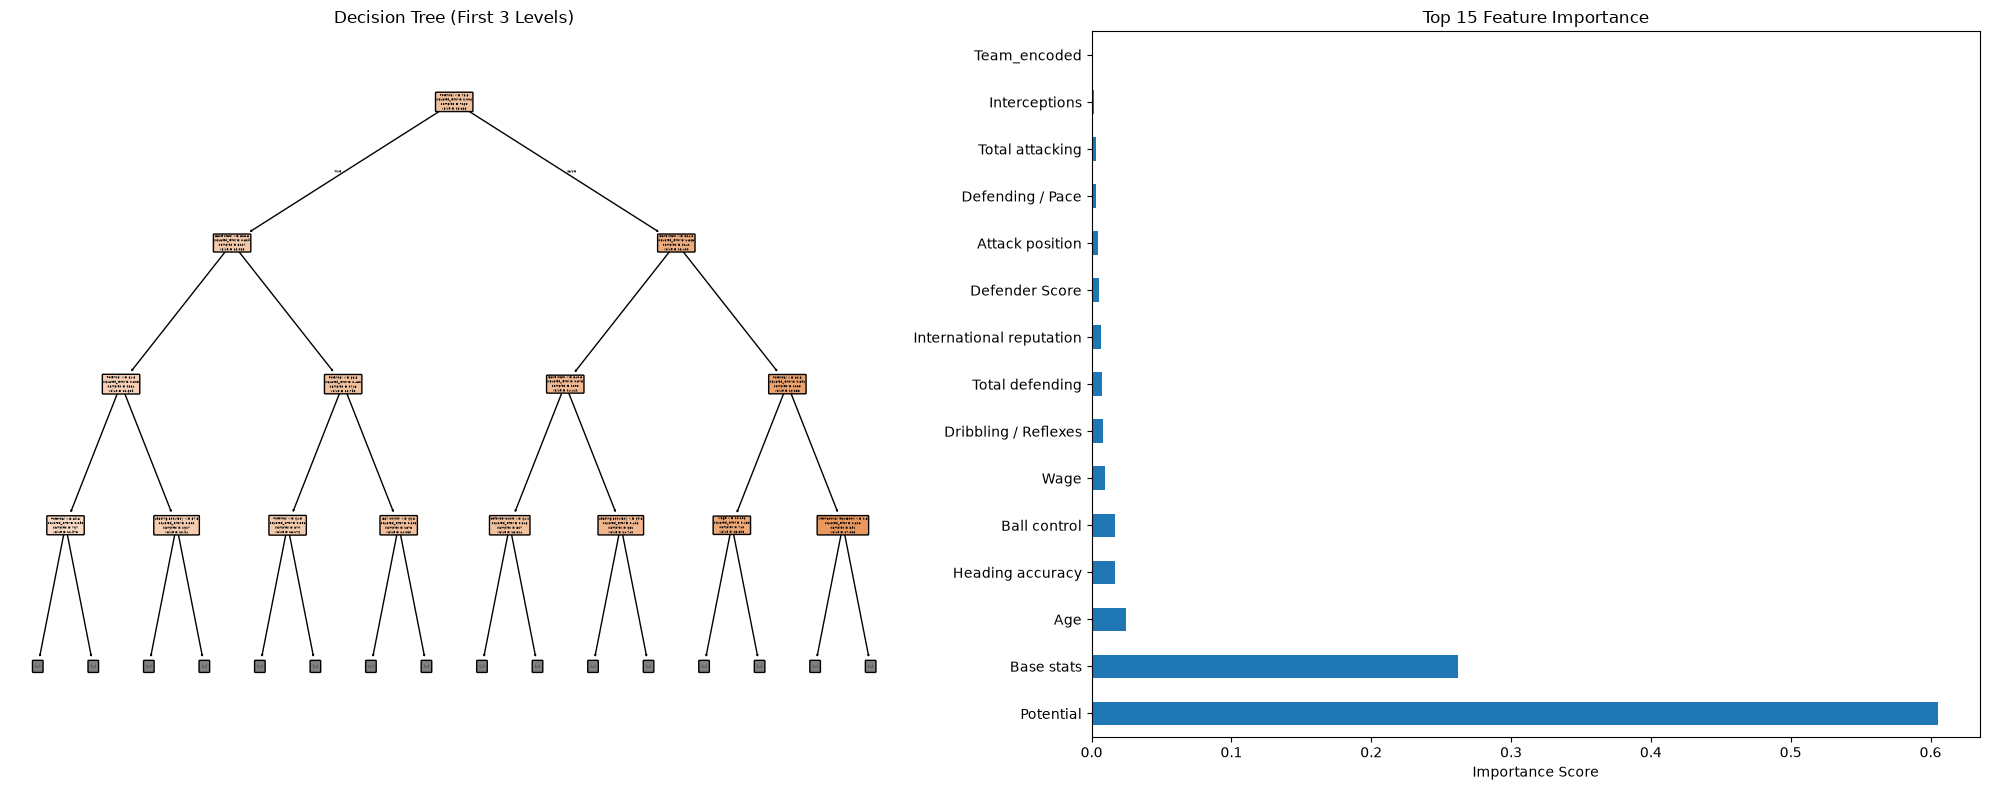

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import plot_tree

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

plot_tree(dt_model, max_depth=3, feature_names=X.columns, 
          filled=True, rounded=True, ax=ax1)
ax1.set_title('Decision Tree (First 3 Levels)')

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_15_features = importances.sort_values(ascending=False)[:15]
top_15_features.plot(kind='barh', ax=ax2)
ax2.set_title('Top 15 Feature Importance')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


In [61]:
joblib.dump(dt_model, '../models/decision_tree_model_0.9493.pkl')


['../models/decision_tree_model_0.9493.pkl']

Decision tree is more likely to overfits

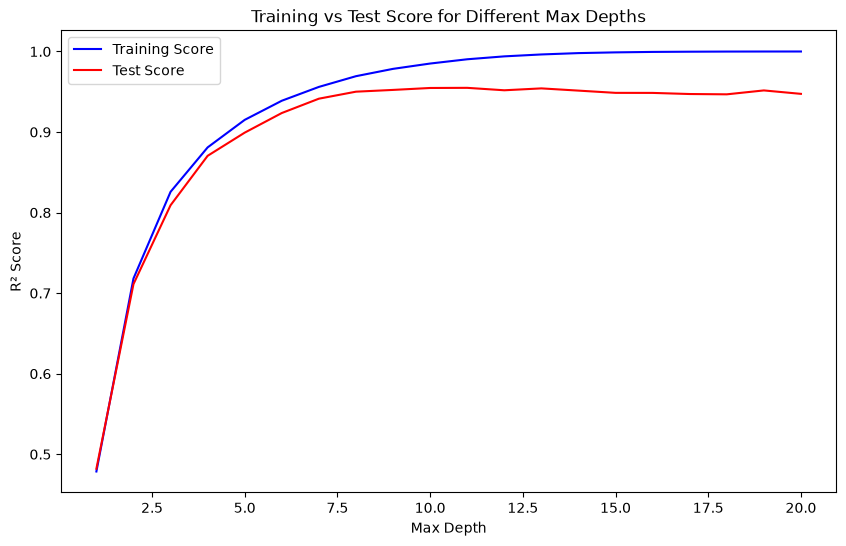

In [62]:
X = df.drop('Value', axis=1)
y = df['Value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

max_depths = np.arange(1, 21)

train_scores = []
test_scores = []

for depth in max_depths:
    dt_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_model.fit(X_train, y_train)
    
    train_scores.append(dt_model.score(X_train, y_train))  
    test_scores.append(dt_model.score(X_test, y_test))  

plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, label='Training Score', color='blue')
plt.plot(max_depths, test_scores, label='Test Score', color='red')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Training vs Test Score for Different Max Depths')
plt.legend()
plt.show()


overfits a little bit

## 5. Let's try Hyperparams tuning to get the best model

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [64]:
param_grid = {
    'max_depth': [2, 5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 10, 20, 30, 40],
    'min_samples_leaf': [1, 5, 8, 10, 15],
    'max_features': ['auto', 'sqrt', 'log2', None]
}

In [65]:
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

f:\Projects\Football Player Evaluation\football\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
875 fits failed out of a total of 3500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
438 fits failed with the following error:
Traceback (most recent call last):
  File "f:\Projects\Football Player Evaluation\football\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "f:\Projects\Football Player Evaluation\football\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "f:\Projects\Football P

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 5, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [66]:
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best Score: -0.0948855859635683


In [67]:
best_dt_model = grid_search.best_estimator_

In [68]:
y_pred = best_dt_model.predict(X_test)
print(f"R² (Best Model- after gridserachCV): {r2_score(y_test, y_pred)}")
print(f"MSE (Best Model): {mean_squared_error(y_test, y_pred)}")

R² (Best Model- after gridserachCV): 0.959035601302462
MSE (Best Model): 0.08448507231497274


 After hyperparameter tuning, we only achieved a marginal increase in model accuracy, suggesting that the additional computational cost may not be justified. so we going to finalize this notebook here. 